This file is a Juypter NoteBook version of the py files of Backterder documentation web page:

https://www.backtrader.com/docu/order-creation-execution/bracket/bracket/

The goal is go step-by-step in code to understand the use of "Bracket Orders"

In [84]:
# Use this if plotting capabilities are wished, This pulls in matplotlib which will in turn pull in other dependencies. !!
# %pip install backtrader[plotting]

### Importing libraries

In [85]:
from __future__ import (absolute_import, division, print_function,unicode_literals)

In [86]:
import argparse
import datetime
import backtrader as bt


### Define Strategy

In [87]:

class St(bt.Strategy):
    params = dict(
        ma=bt.ind.SMA,
        p1=5,
        p2=15,
        limit=0.005,
        limdays=3,
        limdays2=1000,
        hold=10,
        usebracket=False,  # use order_target_size
        switchp1p2=False,  # switch prices of order1 and order2
    )

    def notify_order(self, order):
        print('{}: Order ref: {} / Type {} / Status {}'.format(
            self.data.datetime.date(0),
            order.ref, 'Buy' * order.isbuy() or 'Sell',
            order.getstatusname()))

        if order.status == order.Completed:
            self.holdstart = len(self)

        if not order.alive() and order.ref in self.orefs:
            self.orefs.remove(order.ref)

    def __init__(self):
        ma1, ma2 = self.p.ma(period=self.p.p1), self.p.ma(period=self.p.p2)
        self.cross = bt.ind.CrossOver(ma1, ma2)

        self.orefs = list()

        if self.p.usebracket:
            print('-' * 5, 'Using buy_bracket')

    def next(self):
        if self.orefs:
            return  # pending orders do nothing

        if not self.position:
            if self.cross > 0.0:  # crossing up

                close = self.data.close[0]
                p1 = close * (1.0 - self.p.limit)
                p2 = p1 - 0.02 * close
                p3 = p1 + 0.02 * close

                valid1 = datetime.timedelta(self.p.limdays)
                valid2 = valid3 = datetime.timedelta(self.p.limdays2)

                if self.p.switchp1p2:
                    p1, p2 = p2, p1
                    valid1, valid2 = valid2, valid1

                if not self.p.usebracket:
                    o1 = self.buy(exectype=bt.Order.Limit,
                                  price=p1,
                                  valid=valid1,
                                  transmit=False)

                    print('{}: Oref {} / Buy at {}'.format(
                        self.datetime.date(), o1.ref, p1))

                    o2 = self.sell(exectype=bt.Order.Stop,
                                   price=p2,
                                   valid=valid2,
                                   parent=o1,
                                   transmit=False)

                    print('{}: Oref {} / Sell Stop at {}'.format(
                        self.datetime.date(), o2.ref, p2))

                    o3 = self.sell(exectype=bt.Order.Limit,
                                   price=p3,
                                   valid=valid3,
                                   parent=o1,
                                   transmit=True)

                    print('{}: Oref {} / Sell Limit at {}'.format(
                        self.datetime.date(), o3.ref, p3))

                    self.orefs = [o1.ref, o2.ref, o3.ref]

                else:
                    os = self.buy_bracket(
                        price=p1, valid=valid1,
                        stopprice=p2, stopargs=dict(valid=valid2),
                        limitprice=p3, limitargs=dict(valid=valid3),)

                    self.orefs = [o.ref for o in os]

        else:  # in the market
            if (len(self) - self.holdstart) >= self.p.hold:
                pass  # do nothing in this case





### Defining arguments parser

In [90]:
def parse_args(pargs=None):
    parser = argparse.ArgumentParser(
        formatter_class=argparse.ArgumentDefaultsHelpFormatter,
        description=(
            'Sample Skeleton'
        )
    )

    parser.add_argument('--data0', default='Documents/2005-2006-day-001.txt',
                        required=False, help='Data to read in')

    #  Defaults for dates
    parser.add_argument('--fromdate', required=False, default='',
                        help='Date[time] in YYYY-MM-DD[THH:MM:SS] format')

    parser.add_argument('--todate', required=False, default='',
                        help='Date[time] in YYYY-MM-DD[THH:MM:SS] format')

    parser.add_argument('--cerebro', required=False, default='',
                        metavar='kwargs', help='kwargs in key=value format')

    parser.add_argument('--broker', required=False, default='',
                        metavar='kwargs', help='kwargs in key=value format')

    parser.add_argument('--sizer', required=False, default='',
                        metavar='kwargs', help='kwargs in key=value format')

    parser.add_argument('--strat', required=False, default='',
                        metavar='kwargs', help='kwargs in key=value format')

    parser.add_argument('--plot', required=False, default='',
                        nargs='?', const='{}',
                        metavar='kwargs', help='kwargs in key=value format')

    return parser.parse_args(pargs)


In [91]:
args=None
args = parse_args(args)

In [ ]:
args

Namespace(data0='Documents/2005-2006-day-001.txt', fromdate='c:\\Users\\DELL\\AppData\\Roaming\\jupyter\\runtime\\kernel-v3cb0eac7d549d4dfdeb09346f1ce81b6646f013b1.json', todate='', cerebro='', broker='', sizer='', strat='', plot='')

### Runing the engine

In [ ]:
cerebro = bt.Cerebro()

In [ ]:
# Data feed kwargs
kwargs = dict()

# Parse from/to-date
# dtfmt, tmfmt = '%Y-%m-%d', 'T%H:%M:%S'
# for a, d in ((getattr(args, x), x) for x in ['fromdate', 'todate']):
#     if a:
#        strpfmt = dtfmt + tmfmt * ('T' in a)
#        kwargs[d] = datetime.datetime.strptime(a, strpfmt)

# Data feed
data0 = bt.feeds.BacktraderCSVData(dataname=args.data0, **kwargs)
cerebro.adddata(data0)

# Broker
cerebro.broker = bt.brokers.BackBroker(**eval('dict(' + args.broker + ')'))

    # Sizer
cerebro.addsizer(bt.sizers.FixedSize, **eval('dict(' + args.sizer + ')'))

# Strategy
cerebro.addstrategy(St, **eval('dict(' + args.strat + ')'))

# Execute
cerebro.run(**eval('dict(' + args.cerebro + ')'))



2005-01-28: Oref 1 / Buy at 2941.11055
2005-01-28: Oref 2 / Sell Stop at 2881.99275
2005-01-28: Oref 3 / Sell Limit at 3000.22835
2005-01-31: Order ref: 1 / Type Buy / Status Submitted
2005-01-31: Order ref: 2 / Type Sell / Status Submitted
2005-01-31: Order ref: 3 / Type Sell / Status Submitted
2005-01-31: Order ref: 1 / Type Buy / Status Accepted
2005-01-31: Order ref: 2 / Type Sell / Status Accepted
2005-01-31: Order ref: 3 / Type Sell / Status Accepted
2005-02-01: Order ref: 1 / Type Buy / Status Expired
2005-02-01: Order ref: 2 / Type Sell / Status Canceled
2005-02-01: Order ref: 3 / Type Sell / Status Canceled
2005-03-03: Oref 4 / Buy at 3062.71945
2005-03-03: Oref 5 / Sell Stop at 3001.15725
2005-03-03: Oref 6 / Sell Limit at 3124.28165
2005-03-04: Order ref: 4 / Type Buy / Status Submitted
2005-03-04: Order ref: 5 / Type Sell / Status Submitted
2005-03-04: Order ref: 6 / Type Sell / Status Submitted
2005-03-04: Order ref: 4 / Type Buy / Status Accepted
2005-03-04: Order ref: 5 

In [ ]:
# if args.plot:  # Plot if requested to
#     cerebro.plot(**eval('dict(' + args.plot + ')'))

In [ ]:
%matplotlib inline

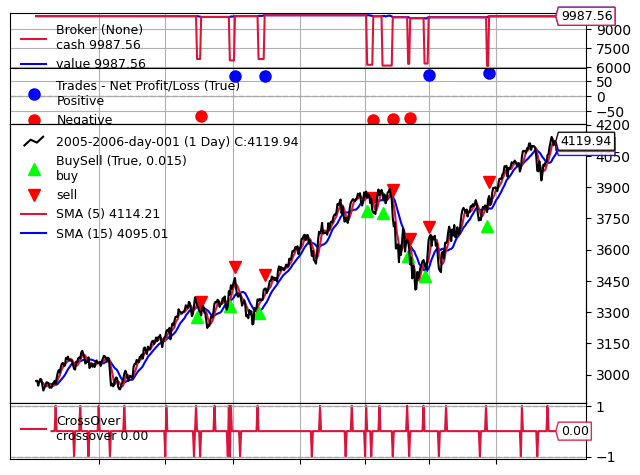

[[<Figure size 640x480 with 5 Axes>]]

In [ ]:
cerebro.plot(iplot=False)